=== 1. RÉGRESSION LINÉAIRE SIMPLE ===
Biais (theta0) : 210666.67
Coefficient (theta1) : -17121.21

=== 2. RÉGRESSION LINÉAIRE MULTIPLE ===
Biais : 219981.74
Coefficients (Âge, Kilométrage) : [-27283.10502283    465.75342466]

=== 3. RÉGRESSION POLYNOMIALE ===
Coefficients (Biais, X, X²) : [226916.66666667 -25246.21212121    738.63636364]



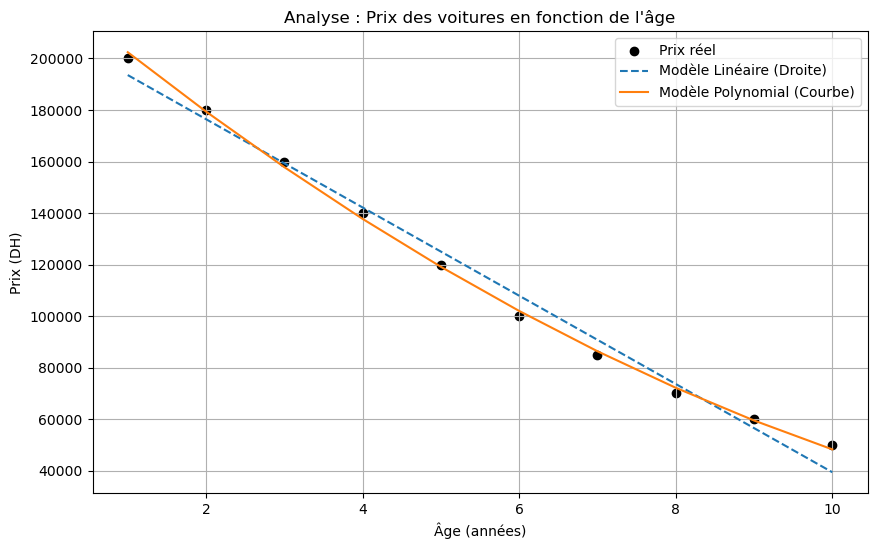

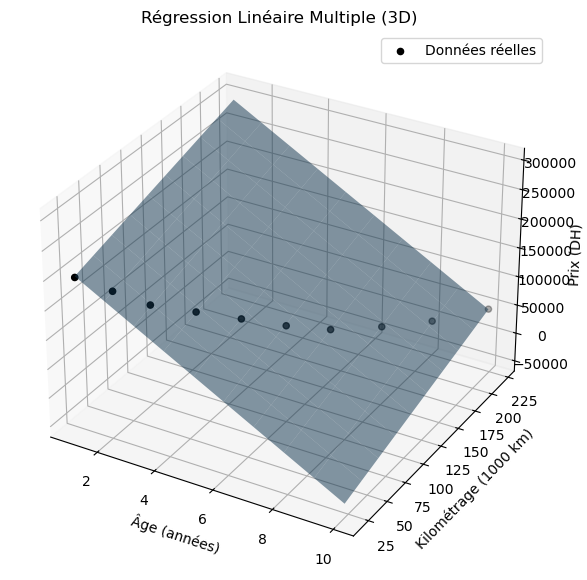

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. PRÉPARATION DES DONNÉES (CAS DES VOITURES)
# =========================================================

# X_simple : Variable explicative unique
# Ici : âge de la voiture (en années)
# Exemple : voiture de 1 an, 2 ans ... jusqu'à 10 ans
X_simple = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

# X_multiple : Deux variables explicatives
# Colonne 1 : âge de la voiture
# Colonne 2 : kilométrage (en milliers de km)
# On étudie ici l'effet combiné âge + kilométrage sur le prix
X_multiple = np.array([[1, 20],[2, 30],[3, 40],[4, 60],[5, 80],[6, 100],[7, 120],[8, 150],[9, 180],[10, 220]])

# y : Variable cible (le prix de la voiture en DH)
# Remarque importante :
# Le prix diminue quand l'âge et le kilométrage augmentent
# Cette relation n'est pas parfaitement linéaire
y = np.array([200000, 180000, 160000, 140000, 120000,100000, 85000, 70000, 60000, 50000])

# =========================================================
# 2. FONCTION PRINCIPALE : ÉQUATION NORMALE
# =========================================================

def fit_scratch(X_input, y_target):
    
    # -----------------------------------------------------
    # ÉTAPE 1 : Ajout du biais (intercept)
    # -----------------------------------------------------
    # En régression, on veut un modèle de type :
    # y = theta0 + theta1*x (+ theta2*x2 ...)
    # Pour intégrer theta0 dans le calcul matriciel,
    # on ajoute une colonne de 1 à la matrice X
    
    X_b = np.c_[np.ones((len(X_input), 1)), X_input]

    # -----------------------------------------------------
    # ÉTAPE 2 : Calcul des paramètres optimaux (theta)
    # -----------------------------------------------------
    # On applique la formule mathématique :
    # theta = (X^T X)^(-1) X^T y
    #
    # .T : transposée de la matrice X
    # dot : produit matriciel
    # .inv : inverse de matrice
    #
    # Cette formule permet de minimiser l'erreur (moindres carrés)

    theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_target)

    # On retourne les paramètres calculés
    return theta_best

# =========================================================
# 3. RÉGRESSION LINÉAIRE SIMPLE
# Modèle : y = a*x + b
# =========================================================

print("=== 1. RÉGRESSION LINÉAIRE SIMPLE ===")

# On transforme X_simple en matrice colonne
# reshape(-1,1) : nécessaire pour le calcul matriciel
theta_simple = fit_scratch(X_simple.reshape(-1, 1), y)

# Affichage des paramètres
print(f"Biais (theta0) : {theta_simple[0]:.2f}")
print(f"Coefficient (theta1) : {theta_simple[1]:.2f}\n")

# Interprétation :
# theta1 indique comment le prix change avec l'âge

# =========================================================
# 4. RÉGRESSION LINÉAIRE MULTIPLE
# Modèle : y = a1*x1 + a2*x2 + b
# =========================================================

print("=== 2. RÉGRESSION LINÉAIRE MULTIPLE ===")

# Ici, le modèle devient :
# y = theta0 + theta1*age + theta2*kilométrage

theta_mult = fit_scratch(X_multiple, y)

print(f"Biais : {theta_mult[0]:.2f}")
print(f"Coefficients (Âge, Kilométrage) : {theta_mult[1:]}\n")

# Interprétation :
# - theta1 : impact de l'âge
# - theta2 : impact du kilométrage

# =========================================================
# 5. RÉGRESSION POLYNOMIALE (DEGRÉ 2)
# Modèle : y = a*x + b*x² + c
# =========================================================

print("=== 3. RÉGRESSION POLYNOMIALE ===")

# Idée clé :
# Si la relation n'est pas linéaire, on ajoute une nouvelle feature
# Ici : x² pour capturer la courbure

X_poly = np.c_[X_simple, X_simple**2]

# Le modèle devient :
# y = theta0 + theta1*x + theta2*x²

theta_poly = fit_scratch(X_poly, y)

print(f"Coefficients (Biais, X, X²) : {theta_poly}\n")

# =========================================================
# 6. VISUALISATION DES RÉSULTATS
# =========================================================

plt.figure(figsize=(10, 6))

# Données réelles (points noirs)
plt.scatter(X_simple, y, color='black', label="Prix réel")

# ------------------------------
# Modèle linéaire
# ------------------------------
# Calcul de la prédiction avec la formule :
# y = theta0 + theta1*x

y_pred_simple = theta_simple[0] + theta_simple[1]*X_simple

plt.plot(X_simple, y_pred_simple,
         linestyle='--',
         label="Modèle Linéaire (Droite)")

# ------------------------------
# Modèle polynomial
# ------------------------------
# y = theta0 + theta1*x + theta2*x²

y_pred_poly = (theta_poly[0] +
               theta_poly[1]*X_simple +
               theta_poly[2]*(X_simple**2))

plt.plot(X_simple, y_pred_poly,
         label="Modèle Polynomial (Courbe)")

# ------------------------------
# Mise en forme du graphique
# ------------------------------
plt.title("Analyse : Prix des voitures en fonction de l'âge")
plt.xlabel("Âge (années)")
plt.ylabel("Prix (DH)")
plt.legend()
plt.grid()

plt.show()

# =========================================================
# 7. VISUALISATION 3D : RÉGRESSION LINÉAIRE MULTIPLE
# =========================================================

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# ------------------------------
# Données réelles (points)
# ------------------------------
age = X_multiple[:, 0]
km = X_multiple[:, 1]

ax.scatter(age, km, y, color='black', label="Données réelles")

# ------------------------------
# Création d'une grille pour le plan
# ------------------------------
age_grid, km_grid = np.meshgrid(np.linspace(age.min(), age.max(), 10),np.linspace(km.min(), km.max(), 10))

# ------------------------------
# Calcul du modèle : plan
# y = theta0 + theta1*age + theta2*km
# ------------------------------
z_pred = (theta_mult[0] +theta_mult[1]*age_grid +theta_mult[2]*km_grid)

# ------------------------------
# Affichage du plan
# ------------------------------
ax.plot_surface(age_grid, km_grid, z_pred, alpha=0.5)

# ------------------------------
# Mise en forme
# ------------------------------
ax.set_title("Régression Linéaire Multiple (3D)")
ax.set_xlabel("Âge (années)")
ax.set_ylabel("Kilométrage (1000 km)")
ax.set_zlabel("Prix (DH)")

plt.legend()
plt.show()